In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [32]:
# Preprocesses the data into pandas dataframes which then can be read easier
def preprocessEmotionData(df):
    # Only takes the items "text" and "label" from each entry in the csv
    df = df[["text", "label"]]
    # Drops the entry from the dataframe if the there is no "text" or "label"
    df = df.dropna(subset=["text", "label"])
    # Fills NaN values in "text" with ""
    df["text"] = df["text"].fillna("")
    return df

In [ ]:
# Trains data and determines metrics
def getMetrics(df, oversampling, k):
    # Lists to store metrics over each of the folds
    accuracyMetrics = []
    precisionMetrics = []
    recallMetrics = []
    f1Metrics = []
    # Defines Kfolds with and a constant "randomness" and shuffling
    kFolds = KFold(n_splits = k, random_state = 1, shuffle = True)
    # Loop through each fold
    for i, j in kFolds.split(df):
        # Splits up the data
        trainingSet = df.iloc[i]
        testingSet = df.iloc[j]
        # Converts the information into TF-IDF features
        # Max features are 5000 because 10000 takes too long
        # ngram range(1,2) is used because this allows for unigrams and bigrams
        # stop_words = "english" removes words like "is", "and", "the" because they are just noise
        vectorizer = TfidfVectorizer(max_features = 5000, ngram_range = (1, 2), stop_words = "english")
        trainTFIDF = vectorizer.fit_transform(trainingSet["text"])
        testTFIDF = vectorizer.transform(testingSet["text"])
        if oversampling == True:
            # Creates OverSampler and uses it to oversample under sampled labels
            ros = RandomOverSampler(random_state = 1)
            X_resampled, y_resampled = ros.fit_resample(trainTFIDF, trainingSet["label"])
            # Naive Bayes Classifier used:
            classifier = MultinomialNB()
            # Trains and classifier and predicts test data
            classifier.fit(X_resampled, y_resampled)
        else:
            # Naive Bayes Classifier used:
            classifier = MultinomialNB()
            # Trains and classifier and predicts test data
            classifier.fit(trainTFIDF, trainingSet["label"])
        prediction = classifier.predict(testTFIDF)
        # Finds requested metrics and adds to their corresponding lists (multiplied by 100 so they can be displayed as % later on)
        accuracyMetrics.append(accuracy_score(testingSet["label"], prediction) * 100)
        precisionMetrics.append(precision_score(testingSet["label"], prediction, average='macro') * 100)
        recallMetrics.append(recall_score(testingSet["label"], prediction, average='macro') * 100)
        f1Metrics.append(f1_score(testingSet["label"], prediction, average='macro') * 100)
    return [accuracyMetrics, sum(accuracyMetrics) / len(accuracyMetrics), precisionMetrics, 
            sum(precisionMetrics) / len(precisionMetrics), recallMetrics,
            sum(recallMetrics) / len(recallMetrics), f1Metrics, sum(f1Metrics) / len(f1Metrics)]

In [ ]:
def plot_metrics(classifier, kFolds, metrics, oversampling):
    # Metrics
    accuracyData = metrics[0]
    accuracyAvg = metrics[1]
    precisionData = metrics[2]
    precisionAvg = metrics[3]
    recallData = metrics[4]
    recallAvg = metrics[5]
    f1Data = metrics[6]
    f1Avg = metrics[7]
    # Indices of the k folds
    x = np.arange(len(kFolds))
    # Creating the figure
    plt.figure(figsize=(10, 6))
    plt.title(f"All Metrics Across {len(kFolds)} K-Folds for {classifier} and Oversampling = {str(oversampling)}")
    plt.xlabel("K-Fold Iteration")
    plt.ylabel("Metric (%)")
    plt.ylim(0, 100)
    plt.xticks(x, kFolds)
    # Plot the bars in the right orientation
    plt.bar(x - 1.5 * 0.2, accuracyData, 0.2, label = "Accuracy")
    plt.bar(x - 0.5 * 0.2, precisionData, 0.2, label = "Precision")
    plt.bar(x + 0.5 * 0.2, recallData, 0.2, label = "Recall")
    plt.bar(x + 1.5 * 0.2, f1Data, 0.2, label = "F1 Score")
    # Add averages for each metric
    plt.axhline(y = accuracyAvg, color = "blue", linestyle = "--", linewidth = 1)
    plt.axhline(y = precisionAvg, color = "orange", linestyle = "--", linewidth = 1)
    plt.axhline(y = recallAvg, color = "green", linestyle = "--", linewidth = 1)
    plt.axhline(y = f1Avg, color = "red", linestyle = "--", linewidth = 1)
    plt.legend()
    plt.tight_layout()
    plt.show()
    # Print out values numerically
    for i in range(len(kFolds)):
        print("K-Fold " + str(kFolds[i]) + ":")
        print("  Accuracy:  " + f"{accuracyData[i]:.2f}" + "%")
        print("  Precision: " + f"{precisionData[i]:.2f}" + "%")
        print("  Recall:    " + f"{recallData[i]:.2f}" + "%")
        print("  F1 Score:  " + f"{f1Data[i]:.2f}" + "%\n")
    print("Averages Across All Folds:")
    print("  Accuracy:  " + f"{accuracyAvg:.2f}" + "%")
    print("  Precision: " + f"{precisionAvg:.2f}" + "%")
    print("  Recall:    " + f"{recallAvg:.2f}" + "%")
    print("  F1 Score:  " + f"{f1Avg:.2f}" + "%\n")


In [ ]:
# Shows the comparison between the average metrics from trainData and the metrics from testData
def displayEvaluationComparison(metricAveragesTrainData, trainData, testData, oversampling):
    # Calculating testData predictions
    vectorizer = TfidfVectorizer(max_features = 5000, ngram_range = (1, 2), stop_words = "english")
    trainTFIDF = vectorizer.fit_transform(trainData["text"])
    testTFIDF = vectorizer.transform(testData["text"])
    if oversampling == True:
        ros = RandomOverSampler(random_state = 1)
        X_resampled, y_resampled = ros.fit_resample(trainTFIDF, trainData["label"])
        classifier = MultinomialNB()
        classifier.fit(X_resampled, y_resampled)
    else:
        classifier = MultinomialNB()
        classifier.fit(trainTFIDF, trainData["label"])
    prediction = classifier.predict(testTFIDF)
    # Displaying averages for each metric on training data
    print("Over Sampling = " + str(oversampling))
    print("Results from Training Data (averaged over all K-Folds):")
    print("Accuracy: " + f"{metricAveragesTrainData[1]:.2f}" + "%")
    print("Precision: " + f"{metricAveragesTrainData[3]:.2f}" + "%")
    print("Recall: " + f"{metricAveragesTrainData[5]:.2f}" + "%")
    print("F1 Score: " + f"{metricAveragesTrainData[7]:.2f}" + "%\n")
    # Displaying averages for each metric on testing data
    print("Results from Testing Data:")
    print("Accuracy: " + f"{accuracy_score(testData['label'], prediction) * 100:.2f}" + "%")
    print("Precision: " + f"{precision_score(testData['label'], prediction, average='macro') * 100:.2f}" + "%")
    print("Recall: " + f"{recall_score(testData['label'], prediction, average='macro') * 100:.2f}" + "%")
    print("F1 Score: " + f"{f1_score(testData['label'], prediction, average='macro') * 100:.2f}" + "%\n")

In [ ]:
# Executes all functions that show metrics (for trainData and testData)
def runOutput(oversampling, trainData, testData, kFolds, k):
    # Finds metrics for the trainData
    NB_metrics = getMetrics(trainData, oversampling, k)
    plot_metrics("Naïve Bayes", kFolds, NB_metrics, oversampling)
    # Shows the comparison between the results of the trainData and testData
    displayEvaluationComparison(NB_metrics, trainData, testData, oversampling)

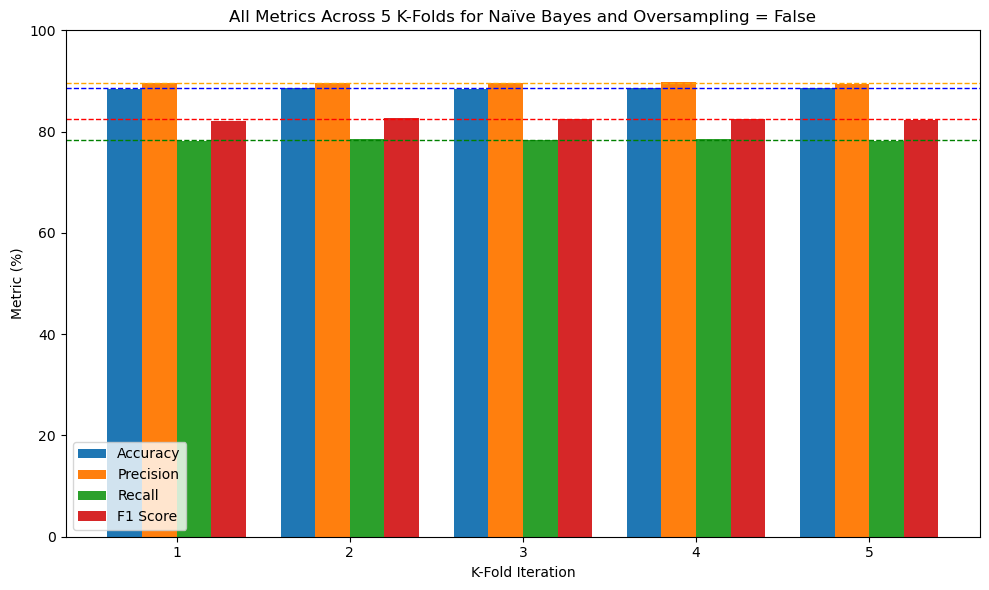

K-Fold 1:
  Accuracy:  88.42%
  Precision: 89.56%
  Recall:    78.05%
  F1 Score:  82.12%

K-Fold 2:
  Accuracy:  88.63%
  Precision: 89.60%
  Recall:    78.58%
  F1 Score:  82.63%

K-Fold 3:
  Accuracy:  88.48%
  Precision: 89.52%
  Recall:    78.39%
  F1 Score:  82.44%

K-Fold 4:
  Accuracy:  88.68%
  Precision: 89.72%
  Recall:    78.54%
  F1 Score:  82.58%

K-Fold 5:
  Accuracy:  88.57%
  Precision: 89.49%
  Recall:    78.24%
  F1 Score:  82.25%

Averages Across All Folds:
  Accuracy:  88.55%
  Precision: 89.58%
  Recall:    78.36%
  F1 Score:  82.41%

Over Sampling = False
Results from Training Data (averaged over all K-Folds):
Accuracy: 88.55%
Precision: 89.58%
Recall: 78.36%
F1 Score: 82.41%

Results from Testing Data:
Accuracy: 88.71%
Precision: 89.43%
Recall: 78.58%
F1 Score: 82.54%



In [37]:
# Running/Obtaining output from HW3 dataset
df = pd.read_csv("text.csv")
df_new = preprocessEmotionData(df)
# Split data into trainData and TestData, where 80% is the trainData and 20% is the testData
trainData, testData = train_test_split(df_new, test_size = 0.2, random_state = 1, stratify=df_new["label"])
k = 5 # Number of folds
kFolds = list(range(1, k + 1))
# Running with oversampling as false
oversampling = False
runOutput(oversampling, trainData, testData, kFolds, k)

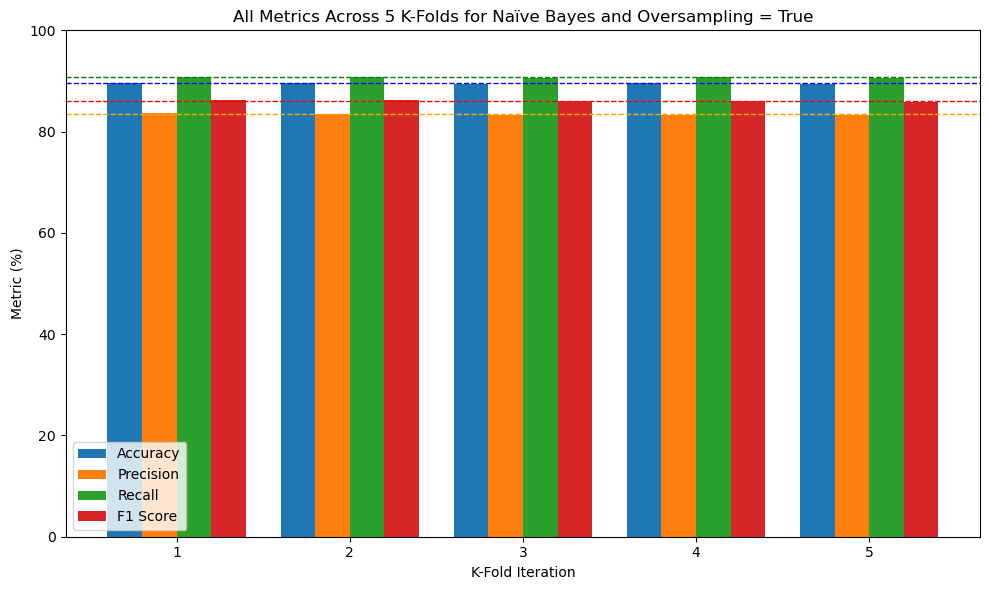

K-Fold 1:
  Accuracy:  89.60%
  Precision: 83.64%
  Recall:    90.77%
  F1 Score:  86.32%

K-Fold 2:
  Accuracy:  89.57%
  Precision: 83.51%
  Recall:    90.79%
  F1 Score:  86.21%

K-Fold 3:
  Accuracy:  89.45%
  Precision: 83.36%
  Recall:    90.63%
  F1 Score:  86.06%

K-Fold 4:
  Accuracy:  89.55%
  Precision: 83.35%
  Recall:    90.74%
  F1 Score:  86.12%

K-Fold 5:
  Accuracy:  89.43%
  Precision: 83.20%
  Recall:    90.54%
  F1 Score:  85.94%

Averages Across All Folds:
  Accuracy:  89.52%
  Precision: 83.41%
  Recall:    90.69%
  F1 Score:  86.13%

Over Sampling = True
Results from Training Data (averaged over all K-Folds):
Accuracy: 89.52%
Precision: 83.41%
Recall: 90.69%
F1 Score: 86.13%

Results from Testing Data:
Accuracy: 89.55%
Precision: 83.40%
Recall: 90.81%
F1 Score: 86.14%



In [38]:
# Running with oversampling as True
oversampling = True
runOutput(oversampling, trainData, testData, kFolds, k)